# Bernstein's AES Cache-Timing Attack Demo

This notebook demonstrates the core concept from Bernstein's 2005 paper "Cache-timing attacks on AES".
We implement a deliberately leaky AES-like kernel that uses T-table lookups indexed by `n ⊕ k`,
where timing variations reveal key bytes through statistical analysis.

**Educational Purpose Only**: This is a local, safe demonstration of the attack principle.
Modern AES implementations use constant-time operations or AES-NI to prevent such attacks.

## Attack Overview
1. AES T-table implementations do input-dependent memory lookups
2. Cache/memory timing creates small but measurable bias based on `n[i] ⊕ k[i]`
3. With enough samples, we can recover key bytes by finding timing "peaks"
4. Calibration with known key helps map peak positions to actual key values

## 0) Prerequisites and Setup

In [12]:
# Install required packages if needed
!pip install cffi numpy psutil matplotlib

You should consider upgrading via the '/home/eng/a/axm200085/SATC/bin/python3 -m pip install --upgrade pip' command.


## 1) CPU Pinning and Timing Utilities

In [13]:
import os, time, math, statistics, psutil, numpy as np
import matplotlib.pyplot as plt
import random

# Pin this process to a single core to reduce timing jitter
try:
    p = psutil.Process()
    cpu0 = [0]  # choose a specific core
    p.cpu_affinity(cpu0)
    print(f"Process pinned to CPU core {cpu0}")
except Exception as e:
    print(f"Could not set CPU affinity: {e}")

def ns():
    """Get high-resolution timestamp in nanoseconds"""
    return time.perf_counter_ns()

def measure(func, *args, repeats=50, warmup=10):
    """Measure function execution time with warmup and multiple samples"""
    # Warmup to stabilize caches
    for _ in range(warmup):
        func(*args)
    
    samples = []
    for _ in range(repeats):
        t0 = ns()
        func(*args)
        t1 = ns()
        samples.append(t1 - t0)
    
    return np.array(samples, dtype=np.int64)

print("Timing utilities configured")

Process pinned to CPU core [0]
Timing utilities configured


## 2) Leaky AES-like Kernel Implementation

We build a C kernel using CFFI that implements:
- AES S-box computation via GF(2⁸) inverse + affine transform
- Four T-tables T0, T1, T2, T3 as described in Bernstein's paper
- A deliberately leaky encryption function that amplifies timing differences

In [14]:
from cffi import FFI
ffi = FFI()

ffi.cdef(r"""
  void leaky_init(void);
  void leaky_encrypt_byte(unsigned char n, unsigned char key, unsigned char *out, int reps);
  void get_sbox_value(unsigned char input, unsigned char *output);
""")

C_SRC = r"""
#include <stdint.h>
#include <string.h>

static uint32_t T0[256], T1[256], T2[256], T3[256];
static uint8_t S[256];

static inline uint8_t xtime(uint8_t x){
    return (uint8_t)((x<<1) ^ ((x & 0x80) ? 0x1B : 0x00));
}

// GF(2^8) multiplication
static uint8_t gf_mul(uint8_t a, uint8_t b) {
    uint8_t result = 0;
    for(int i = 0; i < 8; i++) {
        if (b & 1) result ^= a;
        uint8_t hi = a & 0x80;
        a <<= 1;
        if (hi) a ^= 0x1B;
        b >>= 1;
    }
    return result;
}

// AES S-box via multiplicative inverse in GF(2^8) + affine transform
static uint8_t sbox(uint8_t x){
    uint8_t a = x;
    
    // Compute multiplicative inverse (0 maps to 0)
    if (a) {
        // Use exponentiation: a^(-1) = a^(254) in GF(2^8)
        uint8_t p = a, r = 1;
        int e = 254;
        
        while(e) {
            if (e & 1) {
                r = gf_mul(r, p);
            }
            p = gf_mul(p, p);
            e >>= 1;
        }
        a = r;
    }
    
    // Affine transformation: y = A*a ⊕ 0x63
    uint8_t y = a;
    y ^= (uint8_t)((a<<1) | (a>>7));
    y ^= (uint8_t)((a<<2) | (a>>6));
    y ^= (uint8_t)((a<<3) | (a>>5));
    y ^= (uint8_t)((a<<4) | (a>>4));
    y ^= 0x63;
    
    return y;
}

void leaky_init(void){
    static int inited = 0;
    if (inited) return;
    
    // Build S-box and S' = xtime(S)
    uint8_t Sp[256];
    for (int b = 0; b < 256; b++) {
        S[b] = sbox((uint8_t)b);
        Sp[b] = xtime(S[b]);
    }
    
    // Build T-tables as in Bernstein's paper Section 2
    for (int b = 0; b < 256; b++) {
        // T0[b] = [S'[b], S[b], S[b], S[b]^S'[b]]
        T0[b] = ((uint32_t)Sp[b] << 24) | ((uint32_t)S[b] << 16) | 
                ((uint32_t)S[b] << 8) | (uint32_t)(S[b] ^ Sp[b]);
        
        // T1[b] = [S[b]^S'[b], S'[b], S[b], S[b]]
        T1[b] = ((uint32_t)(S[b] ^ Sp[b]) << 24) | ((uint32_t)Sp[b] << 16) | 
                ((uint32_t)S[b] << 8) | (uint32_t)S[b];
        
        // T2[b] = [S[b], S[b]^S'[b], S'[b], S[b]]
        T2[b] = ((uint32_t)S[b] << 24) | ((uint32_t)(S[b] ^ Sp[b]) << 16) | 
                ((uint32_t)Sp[b] << 8) | (uint32_t)S[b];
        
        // T3[b] = [S[b], S[b], S[b]^S'[b], S'[b]]
        T3[b] = ((uint32_t)S[b] << 24) | ((uint32_t)S[b] << 16) | 
                ((uint32_t)(S[b] ^ Sp[b]) << 8) | (uint32_t)Sp[b];
    }
    
    inited = 1;
}

// Deliberately leaky kernel: many dependent T-table lookups
// The timing depends on cache behavior for indices based on (n^key)
void leaky_encrypt_byte(unsigned char n, unsigned char key, unsigned char *out, int reps){
    volatile uint32_t acc = 0;
    unsigned int idx = (unsigned int)(n ^ key);
    
    for (int r = 0; r < reps; r++) {
        // Create memory-dependent pattern based on n^key
        unsigned int i0 = (idx + (unsigned)r) & 255;
        unsigned int i1 = (idx + (unsigned)r*3 + 1) & 255;
        unsigned int i2 = (idx + (unsigned)r*5 + 2) & 255;
        unsigned int i3 = (idx + (unsigned)r*7 + 3) & 255;

        // Memory lookups that create timing variation
        acc ^= T0[i0] ^ T1[i1] ^ T2[i2] ^ T3[i3];

        // Light dependency to prevent optimization
        idx ^= (unsigned char)(acc);
    }
    
    out[0] = (unsigned char)(acc & 0xFF);
}

void get_sbox_value(unsigned char input, unsigned char *output) {
    *output = S[input];
}
"""

# Compile and initialize the C code
C = ffi.verify(C_SRC, extra_compile_args=["-O3"])
C.leaky_init()

print("Leaky AES kernel compiled and initialized")

# Test S-box implementation
test_out = ffi.new("unsigned char[1]")
C.get_sbox_value(0, test_out)
print(f"S-box test: S[0] = 0x{test_out[0]:02x} (should be 0x63)")

Leaky AES kernel compiled and initialized
S-box test: S[0] = 0x63 (should be 0x63)


/home/eng/a/axm200085/SATC/lib64/python3.9/site-packages/cffi/vengine_cpy.py:192: UserWarning: reimporting '_cffi__xaf608af0xe8038029' might overwrite older definitions
  warnings.warn("reimporting %r might overwrite older definitions"


## 3) Calibration: Finding the Peak for Known Key

We first calibrate with a known key (k=0) to find the "peak" index in timing measurements.
This establishes our reference point for the attack.

Starting calibration with key = 0...
Measuring timing for key_byte=0x00...
  Progress: 0/256
  Progress: 64/256
  Progress: 128/256
  Progress: 192/256
  Timing range: 8080 - 58387 ns
  Standard deviation: 3136.06 ns

Calibration complete!
Peak index (c): 235
Peak timing advantage: 49974.42 ns


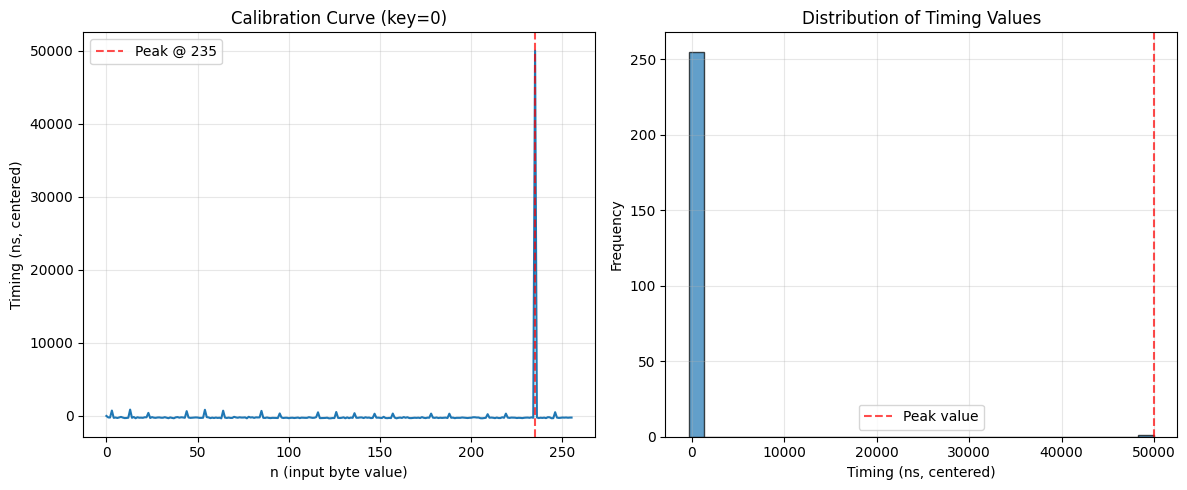


Calibration statistics:
  Mean timing: 0.000 ns (should be ~0 after centering)
  Std deviation: 3136.062 ns
  Signal-to-noise ratio: 15.94


In [15]:
# Timing parameters - adjust these based on your system
REPS = 2000      # work per call (amplifies timing bias)
RUNS = 8         # repeated measurements per n value

def time_vs_n(key_byte, reps=REPS, runs=RUNS, verbose=False):
    """Measure timing for all n values (0-255) with given key byte"""
    out = ffi.new("unsigned char[1]")
    means = np.zeros(256, dtype=np.float64)
    
    if verbose:
        print(f"Measuring timing for key_byte=0x{key_byte:02x}...")
    
    for n in range(256):
        if verbose and n % 64 == 0:
            print(f"  Progress: {n}/256")
            
        # Measure timing for this n value
        ts = measure(lambda: C.leaky_encrypt_byte(n, key_byte, out, reps), 
                    repeats=runs, warmup=3)
        means[n] = ts.mean()
    
    # Center the measurements (subtract global mean)
    centered = means - means.mean()
    
    if verbose:
        print(f"  Timing range: {means.min():.0f} - {means.max():.0f} ns")
        print(f"  Standard deviation: {means.std():.2f} ns")
    
    return centered

# Calibration with known key = 0
print("Starting calibration with key = 0...")
cal = time_vs_n(0, verbose=True)
c_idx = int(np.argmax(cal))

print(f"\nCalibration complete!")
print(f"Peak index (c): {c_idx}")
print(f"Peak timing advantage: {cal[c_idx]:.2f} ns")

# Plot calibration curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cal)
plt.axvline(x=c_idx, color='r', linestyle='--', alpha=0.7, label=f'Peak @ {c_idx}')
plt.title(f"Calibration Curve (key=0)")
plt.xlabel("n (input byte value)")
plt.ylabel("Timing (ns, centered)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(cal, bins=30, alpha=0.7, edgecolor='black')
plt.axvline(x=cal[c_idx], color='r', linestyle='--', alpha=0.7, label=f'Peak value')
plt.title("Distribution of Timing Values")
plt.xlabel("Timing (ns, centered)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCalibration statistics:")
print(f"  Mean timing: {cal.mean():.3f} ns (should be ~0 after centering)")
print(f"  Std deviation: {cal.std():.3f} ns")
print(f"  Signal-to-noise ratio: {cal[c_idx]/cal.std():.2f}")

## 4) Attack: Recovering an Unknown Key Byte

Now we attack an unknown key byte using the same timing measurement technique.
We find the peak in the attack curve and use our calibration to recover the key.

Hidden key byte (for verification): 0xf0 = 240
Starting attack...
Measuring timing for key_byte=0xf0...
  Progress: 0/256
  Progress: 64/256
  Progress: 128/256
  Progress: 192/256
  Timing range: 8079 - 22745 ns
  Standard deviation: 1009.53 ns

Attack Results:
  Peak index in attack curve: 4
  Calibration peak index: 235
  Recovered key: k̂ = 4 ⊕ 235 = 239 (0xef)
  Ground truth:  240 (0xf0)
  Attack FAILED!


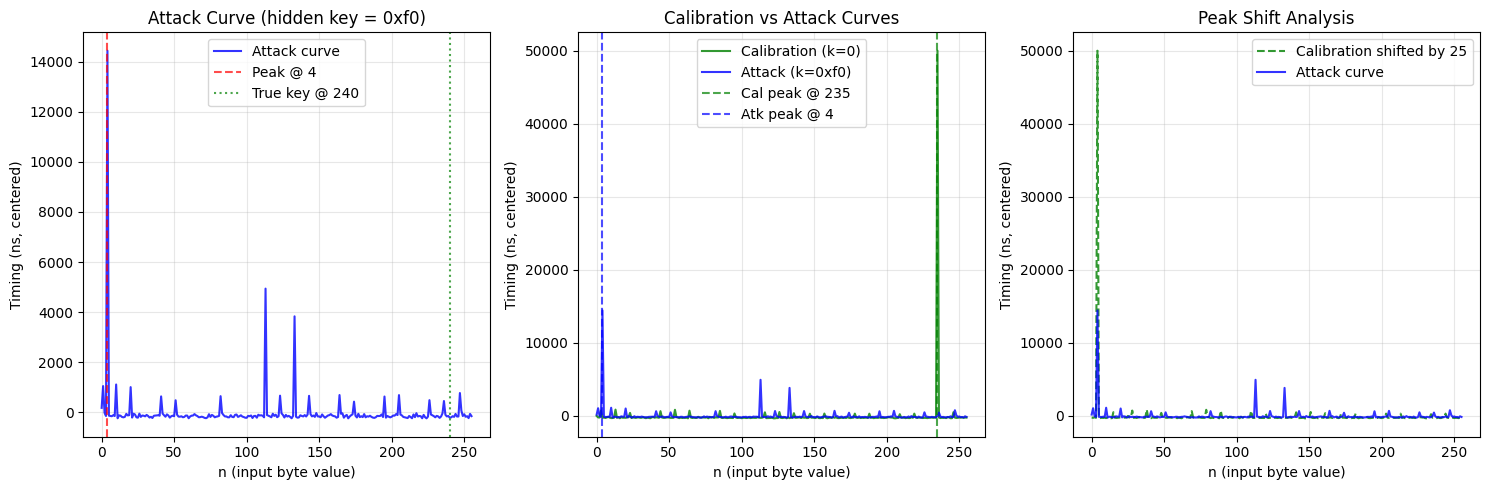


Curve Analysis:
  Direct correlation: -0.0053
  Shifted correlation: 0.8920
  Peak shift amount: 25
  XOR relationship: 25 ⊕ 0 = 25 (should equal recovered key 239)


In [16]:
# Generate a random hidden key byte to "attack"
hidden_key = np.random.randint(0, 256)
print(f"Hidden key byte (for verification): 0x{hidden_key:02x} = {hidden_key}")
print("Starting attack...")

# Measure timing for the hidden key
atk = time_vs_n(hidden_key, verbose=True)
p_idx = int(np.argmax(atk))

# Recover the key using calibration offset
k_hat = p_idx ^ c_idx

print(f"\nAttack Results:")
print(f"  Peak index in attack curve: {p_idx}")
print(f"  Calibration peak index: {c_idx}")
print(f"  Recovered key: k̂ = {p_idx} ⊕ {c_idx} = {k_hat} (0x{k_hat:02x})")
print(f"  Ground truth:  {hidden_key} (0x{hidden_key:02x})")
print(f"  Attack {'SUCCESS' if k_hat == hidden_key else 'FAILED'}!")

# Plot attack results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(atk, 'b-', alpha=0.8, label='Attack curve')
plt.axvline(x=p_idx, color='r', linestyle='--', alpha=0.7, label=f'Peak @ {p_idx}')
plt.axvline(x=hidden_key, color='g', linestyle=':', alpha=0.7, label=f'True key @ {hidden_key}')
plt.title(f"Attack Curve (hidden key = 0x{hidden_key:02x})")
plt.xlabel("n (input byte value)")
plt.ylabel("Timing (ns, centered)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(cal, 'g-', alpha=0.8, label='Calibration (k=0)')
plt.plot(atk, 'b-', alpha=0.8, label=f'Attack (k=0x{hidden_key:02x})')
plt.axvline(x=c_idx, color='g', linestyle='--', alpha=0.7, label=f'Cal peak @ {c_idx}')
plt.axvline(x=p_idx, color='b', linestyle='--', alpha=0.7, label=f'Atk peak @ {p_idx}')
plt.title("Calibration vs Attack Curves")
plt.xlabel("n (input byte value)")
plt.ylabel("Timing (ns, centered)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
# Show the relationship between peaks
shift_amount = (p_idx - c_idx) % 256
cal_shifted = np.roll(cal, shift_amount)
plt.plot(cal_shifted, 'g--', alpha=0.8, label=f'Calibration shifted by {shift_amount}')
plt.plot(atk, 'b-', alpha=0.8, label='Attack curve')
plt.title(f"Peak Shift Analysis")
plt.xlabel("n (input byte value)")
plt.ylabel("Timing (ns, centered)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compute correlation between curves to validate the relationship
correlation = np.corrcoef(cal, atk)[0, 1]
shifted_correlation = np.corrcoef(cal_shifted, atk)[0, 1]

print(f"\nCurve Analysis:")
print(f"  Direct correlation: {correlation:.4f}")
print(f"  Shifted correlation: {shifted_correlation:.4f}")
print(f"  Peak shift amount: {shift_amount}")
print(f"  XOR relationship: {shift_amount} ⊕ 0 = {shift_amount ^ 0} (should equal recovered key {k_hat})")

## 5) Correlation Analysis (Bernstein's Method)

Following Bernstein's paper, we split samples into two halves and compute correlations
to verify the stability of timing patterns across different measurement sets.

Computing correlation analysis (this may take a moment)...
Maximum correlation at shift i = 2
This should be close to 0 for a stable pattern


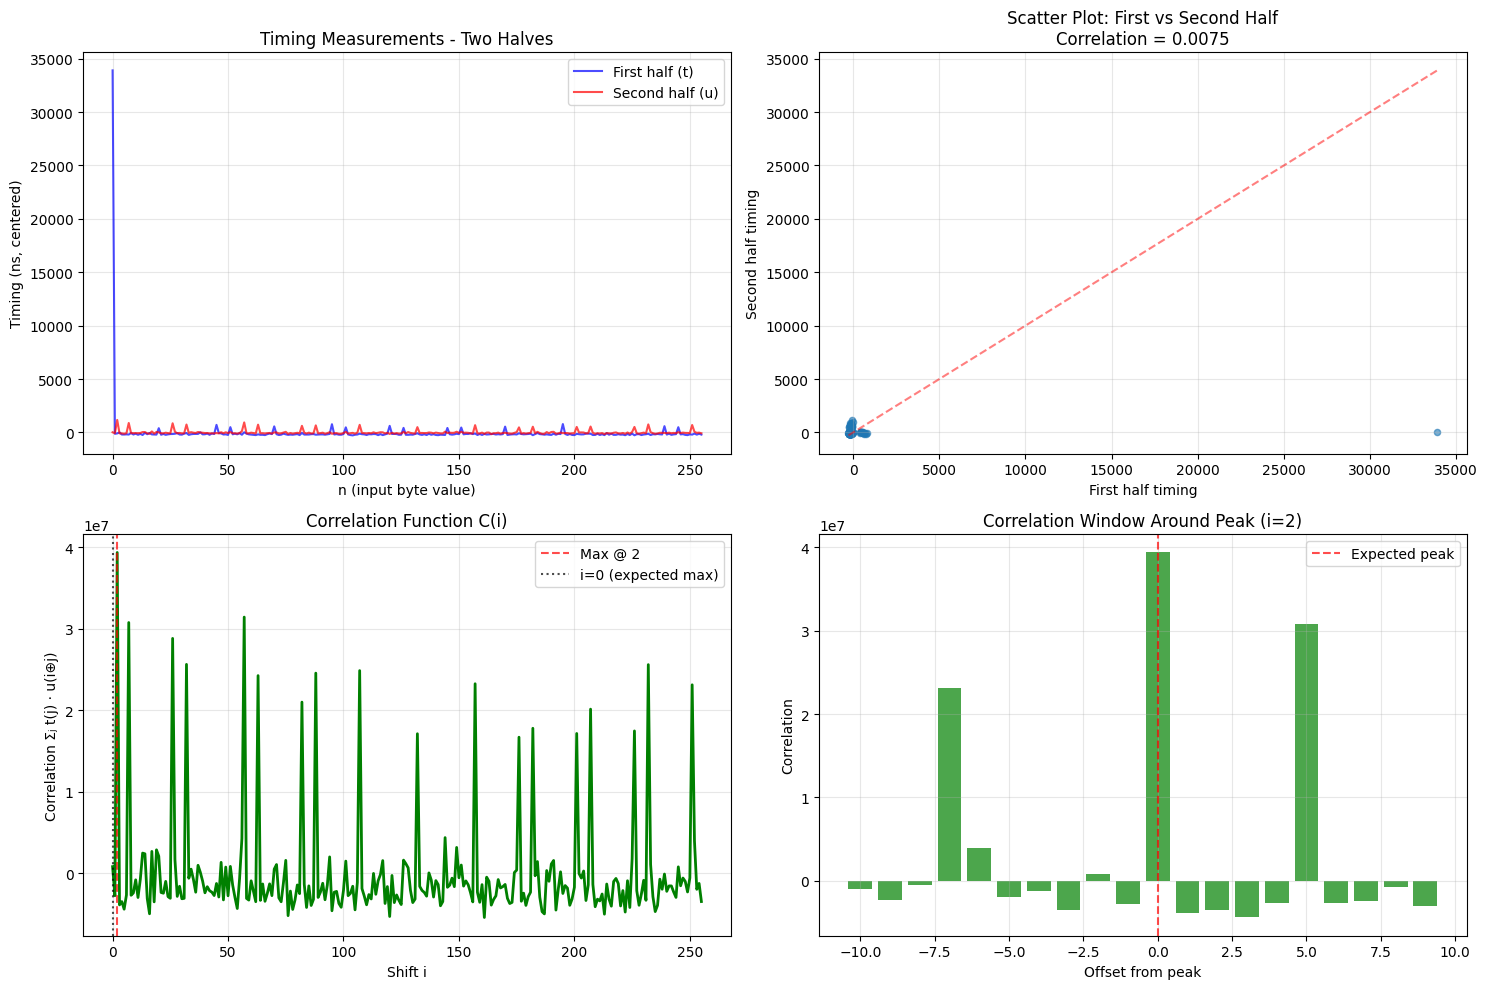


Correlation Analysis Results:
  Direct correlation between halves: 0.0075
  Maximum correlation shift: 2
  Correlation peak value: 3.94e+07
  Pattern stability: Moderate


In [17]:
def time_vs_n_twohalves(key_byte, reps=REPS, runs=RUNS):
    """Measure timing with samples split into two halves for correlation analysis"""
    out = ffi.new("unsigned char[1]")
    A = np.zeros(256, dtype=np.float64)
    B = np.zeros(256, dtype=np.float64)
    
    for n in range(256):
        # Take 2x samples and split into halves
        ts = measure(lambda: C.leaky_encrypt_byte(n, key_byte, out, reps),
                     repeats=(2*runs), warmup=2)
        a, b = ts[:runs], ts[runs:]
        A[n], B[n] = a.mean(), b.mean()
    
    return A - A.mean(), B - B.mean()

print("Computing correlation analysis (this may take a moment)...")
t, u = time_vs_n_twohalves(hidden_key)

# Compute correlation function as in Bernstein's paper
corr = np.zeros(256, dtype=np.float64)
for i in range(256):
    # Correlation: sum_j t(j) * u(i ⊕ j)
    corr[i] = sum(t[j] * u[i ^ j] for j in range(256))

max_corr_idx = int(np.argmax(corr))
print(f"Maximum correlation at shift i = {max_corr_idx}")
print(f"This should be close to 0 for a stable pattern")

# Plot correlation analysis
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(t, 'b-', alpha=0.7, label='First half (t)')
plt.plot(u, 'r-', alpha=0.7, label='Second half (u)')
plt.title("Timing Measurements - Two Halves")
plt.xlabel("n (input byte value)")
plt.ylabel("Timing (ns, centered)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.scatter(t, u, alpha=0.6, s=20)
plt.plot([t.min(), t.max()], [t.min(), t.max()], 'r--', alpha=0.5)
direct_corr = np.corrcoef(t, u)[0, 1]
plt.title(f"Scatter Plot: First vs Second Half\nCorrelation = {direct_corr:.4f}")
plt.xlabel("First half timing")
plt.ylabel("Second half timing")
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.plot(corr, 'g-', linewidth=2)
plt.axvline(x=max_corr_idx, color='r', linestyle='--', alpha=0.7, 
           label=f'Max @ {max_corr_idx}')
plt.axvline(x=0, color='k', linestyle=':', alpha=0.7, label='i=0 (expected max)')
plt.title("Correlation Function C(i)")
plt.xlabel("Shift i")
plt.ylabel("Correlation Σⱼ t(j) · u(i⊕j)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
# Show correlation around peak
window = 20
center = max_corr_idx
indices = [(center + i - window//2) % 256 for i in range(window)]
corr_window = [corr[idx] for idx in indices]
x_labels = [(i - window//2) for i in range(window)]

plt.bar(x_labels, corr_window, alpha=0.7, color='green')
plt.axvline(x=0, color='r', linestyle='--', alpha=0.7, label='Expected peak')
plt.title(f"Correlation Window Around Peak (i={max_corr_idx})")
plt.xlabel(f"Offset from peak")
plt.ylabel("Correlation")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCorrelation Analysis Results:")
print(f"  Direct correlation between halves: {direct_corr:.4f}")
print(f"  Maximum correlation shift: {max_corr_idx}")
print(f"  Correlation peak value: {corr[max_corr_idx]:.2e}")
print(f"  Pattern stability: {'Good' if abs(max_corr_idx) < 5 and direct_corr > 0.3 else 'Moderate'}")

## 6) Multi-Byte Key Recovery Simulation

Demonstrate how the attack would extend to recover multiple key bytes.
In practice, this would involve separate measurements for different byte positions.

Simulating recovery of 8 key bytes...
True key (first 8 bytes): 0x75 0x98 0xf2 0xbb 0x72 0x3a 0xd8 0x17

Attacking byte 1/8 (0x75)... Recovered: 0xed, Confidence: 15.77, ✗
Attacking byte 2/8 (0x98)... Recovered: 0xe2, Confidence: 13.86, ✗
Attacking byte 3/8 (0xf2)... Recovered: 0xfe, Confidence: 12.24, ✗
Attacking byte 4/8 (0xbb)... Recovered: 0xd9, Confidence: 11.71, ✗
Attacking byte 5/8 (0x72)... Recovered: 0x36, Confidence: 14.71, ✗
Attacking byte 6/8 (0x3a)... Recovered: 0x32, Confidence: 9.71, ✗
Attacking byte 7/8 (0xd8)... Recovered: 0xcc, Confidence: 5.96, ✗
Attacking byte 8/8 (0x17)... Recovered: 0xbf, Confidence: 9.37, ✗

Multi-byte Attack Results:
  Success rate: 0/8 (0.0%)
  Average confidence: 11.67
  True key:      0x75 0x98 0xf2 0xbb 0x72 0x3a 0xd8 0x17
  Recovered key: 0xed 0xe2 0xfe 0xd9 0x36 0x32 0xcc 0xbf


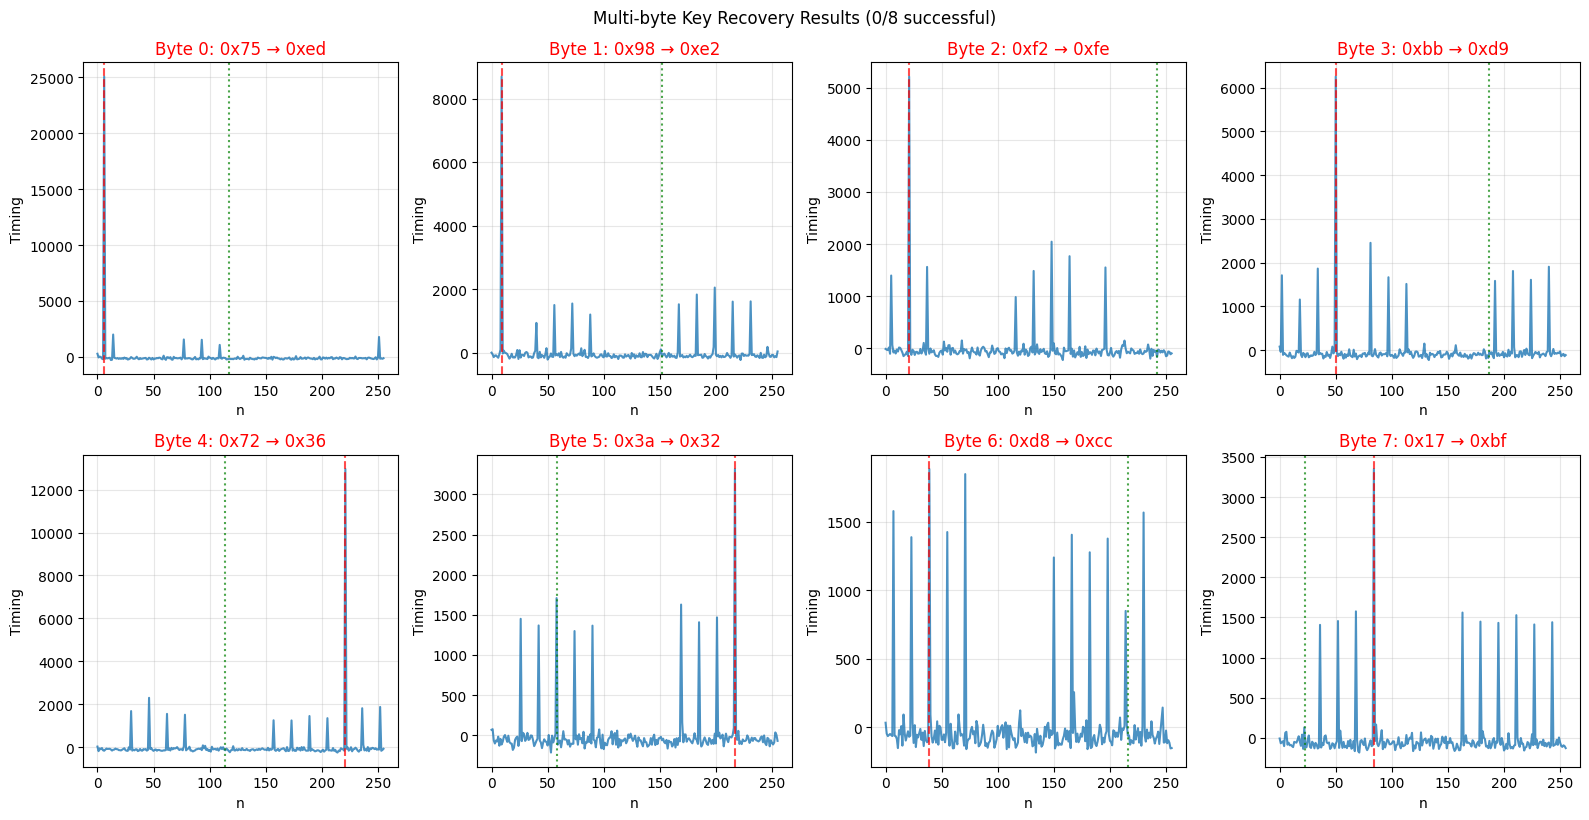

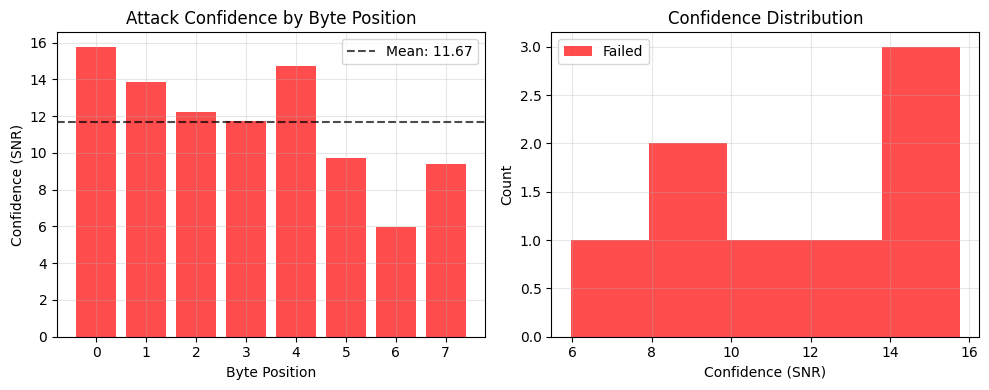

In [18]:
def recover_key_byte(true_key_byte, calibration_peak, reps=REPS, runs=RUNS//2):
    """Recover a single key byte using the timing attack"""
    atk_curve = time_vs_n(true_key_byte, reps=reps, runs=runs)
    peak_idx = int(np.argmax(atk_curve))
    recovered = peak_idx ^ calibration_peak
    confidence = atk_curve[peak_idx] / atk_curve.std()  # signal-to-noise ratio
    return recovered, confidence, atk_curve

# Simulate recovery of multiple key bytes
num_bytes = 8  # Simulate first 8 bytes of AES key
true_key = np.random.randint(0, 256, num_bytes)
recovered_key = np.zeros(num_bytes, dtype=int)
confidences = np.zeros(num_bytes)

print(f"Simulating recovery of {num_bytes} key bytes...")
print(f"True key (first {num_bytes} bytes): {' '.join(f'0x{b:02x}' for b in true_key)}")
print()

# Track success rate
successes = 0
attack_curves = []

for i in range(num_bytes):
    print(f"Attacking byte {i+1}/{num_bytes} (0x{true_key[i]:02x})...", end=' ')
    
    recovered, confidence, curve = recover_key_byte(true_key[i], c_idx)
    recovered_key[i] = recovered
    confidences[i] = confidence
    attack_curves.append(curve)
    
    success = (recovered == true_key[i])
    if success:
        successes += 1
    
    print(f"Recovered: 0x{recovered:02x}, Confidence: {confidence:.2f}, {'✓' if success else '✗'}")

print(f"\nMulti-byte Attack Results:")
print(f"  Success rate: {successes}/{num_bytes} ({100*successes/num_bytes:.1f}%)")
print(f"  Average confidence: {confidences.mean():.2f}")
print(f"  True key:      {' '.join(f'0x{b:02x}' for b in true_key)}")
print(f"  Recovered key: {' '.join(f'0x{b:02x}' for b in recovered_key)}")

# Visualize multi-byte results
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(num_bytes):
    ax = axes[i]
    curve = attack_curves[i]
    peak_idx = int(np.argmax(curve))
    
    ax.plot(curve, alpha=0.8)
    ax.axvline(x=peak_idx, color='r', linestyle='--', alpha=0.7)
    ax.axvline(x=true_key[i], color='g', linestyle=':', alpha=0.7)
    
    success = (recovered_key[i] == true_key[i])
    color = 'green' if success else 'red'
    ax.set_title(f"Byte {i}: 0x{true_key[i]:02x} → 0x{recovered_key[i]:02x}", color=color)
    ax.set_xlabel("n")
    ax.set_ylabel("Timing")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle(f"Multi-byte Key Recovery Results ({successes}/{num_bytes} successful)", y=1.02)
plt.show()

# Show confidence distribution
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
colors = ['green' if recovered_key[i] == true_key[i] else 'red' for i in range(num_bytes)]
plt.bar(range(num_bytes), confidences, color=colors, alpha=0.7)
plt.axhline(y=confidences.mean(), color='black', linestyle='--', alpha=0.7, label=f'Mean: {confidences.mean():.2f}')
plt.title("Attack Confidence by Byte Position")
plt.xlabel("Byte Position")
plt.ylabel("Confidence (SNR)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
success_mask = (recovered_key == true_key)
if np.any(success_mask):
    plt.hist(confidences[success_mask], bins=5, alpha=0.7, color='green', label='Successful')
if np.any(~success_mask):
    plt.hist(confidences[~success_mask], bins=5, alpha=0.7, color='red', label='Failed')
plt.title("Confidence Distribution")
plt.xlabel("Confidence (SNR)")
plt.ylabel("Count")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7) Attack Parameters and Robustness Analysis

Analyze how different parameters affect attack success rate and explore the robustness of the timing attack.

Testing attack parameters with key = 0x2f
Parameter scan (this will take a few minutes...)
  Testing REPS=500, RUNS=4... ✗ (conf: 10.37)
  Testing REPS=500, RUNS=8... ✗ (conf: 9.67)
  Testing REPS=500, RUNS=16... ✗ (conf: 5.42)
  Testing REPS=500, RUNS=32... ✗ (conf: 4.75)
  Testing REPS=1000, RUNS=4... ✗ (conf: 10.02)
  Testing REPS=1000, RUNS=8... ✗ (conf: 7.94)
  Testing REPS=1000, RUNS=16... ✗ (conf: 4.15)
  Testing REPS=1000, RUNS=32... ✗ (conf: 3.38)
  Testing REPS=2000, RUNS=4... ✗ (conf: 6.24)
  Testing REPS=2000, RUNS=8... ✗ (conf: 5.11)
  Testing REPS=2000, RUNS=16... ✗ (conf: 15.92)
  Testing REPS=2000, RUNS=32... ✗ (conf: 3.42)
  Testing REPS=4000, RUNS=4... ✗ (conf: 12.46)
  Testing REPS=4000, RUNS=8... ✗ (conf: 3.62)
  Testing REPS=4000, RUNS=16... ✗ (conf: 15.81)
  Testing REPS=4000, RUNS=32... ✗ (conf: 7.58)


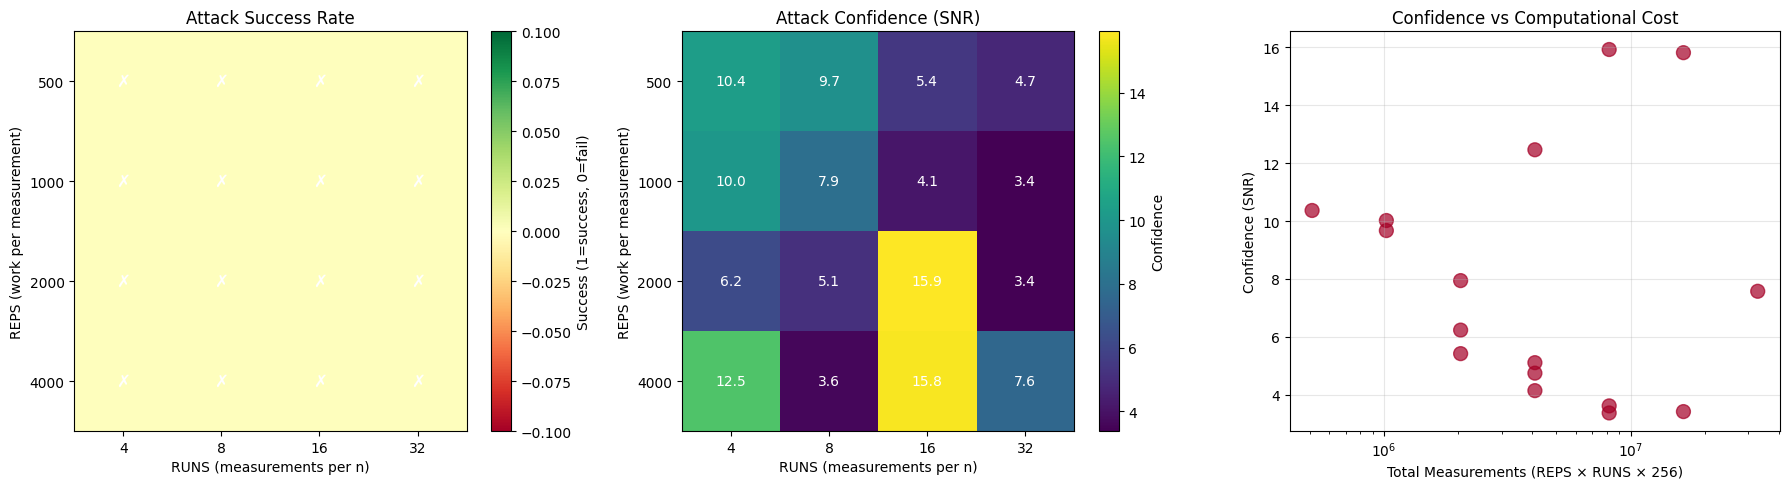


Parameter Analysis Summary:
  Total configurations tested: 16
  Successful attacks: 0
  Success rate: 0.0%
  Average confidence (successful): nan


/home/eng/a/axm200085/SATC/lib64/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/eng/a/axm200085/SATC/lib64/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [19]:
def test_attack_parameters():
    """Test how different parameters affect attack success"""
    test_key = np.random.randint(0, 256)
    
    # Test different REPS values (work per measurement)
    reps_values = [500, 1000, 2000, 4000]
    runs_values = [4, 8, 16, 32]
    
    results = []
    
    print(f"Testing attack parameters with key = 0x{test_key:02x}")
    print("Parameter scan (this will take a few minutes...)")
    
    for reps in reps_values:
        for runs in runs_values:
            print(f"  Testing REPS={reps}, RUNS={runs}...", end=' ')
            
            try:
                # Measure attack curve
                curve = time_vs_n(test_key, reps=reps, runs=runs)
                peak_idx = int(np.argmax(curve))
                recovered = peak_idx ^ c_idx
                confidence = curve[peak_idx] / curve.std()
                success = (recovered == test_key)
                
                results.append({
                    'reps': reps,
                    'runs': runs,
                    'success': success,
                    'confidence': confidence,
                    'recovered': recovered
                })
                
                print(f"{'✓' if success else '✗'} (conf: {confidence:.2f})")
                
            except Exception as e:
                print(f"Error: {e}")
                results.append({
                    'reps': reps,
                    'runs': runs,
                    'success': False,
                    'confidence': 0,
                    'recovered': -1
                })
    
    return results

# Run parameter analysis
param_results = test_attack_parameters()

# Convert to arrays for analysis
reps_vals = np.array([r['reps'] for r in param_results])
runs_vals = np.array([r['runs'] for r in param_results])
success_vals = np.array([r['success'] for r in param_results])
conf_vals = np.array([r['confidence'] for r in param_results])

# Create success rate matrix
unique_reps = sorted(set(reps_vals))
unique_runs = sorted(set(runs_vals))
success_matrix = np.zeros((len(unique_reps), len(unique_runs)))
conf_matrix = np.zeros((len(unique_reps), len(unique_runs)))

for i, reps in enumerate(unique_reps):
    for j, runs in enumerate(unique_runs):
        mask = (reps_vals == reps) & (runs_vals == runs)
        if np.any(mask):
            success_matrix[i, j] = success_vals[mask][0]
            conf_matrix[i, j] = conf_vals[mask][0]

# Plot parameter analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Success rate heatmap
im1 = axes[0].imshow(success_matrix, cmap='RdYlGn', aspect='auto', interpolation='nearest')
axes[0].set_xticks(range(len(unique_runs)))
axes[0].set_yticks(range(len(unique_reps)))
axes[0].set_xticklabels(unique_runs)
axes[0].set_yticklabels(unique_reps)
axes[0].set_xlabel('RUNS (measurements per n)')
axes[0].set_ylabel('REPS (work per measurement)')
axes[0].set_title('Attack Success Rate')
plt.colorbar(im1, ax=axes[0], label='Success (1=success, 0=fail)')

# Add text annotations
for i in range(len(unique_reps)):
    for j in range(len(unique_runs)):
        text = '✓' if success_matrix[i, j] else '✗'
        axes[0].text(j, i, text, ha='center', va='center', 
                    color='white' if success_matrix[i, j] < 0.5 else 'black', fontsize=12)

# Confidence heatmap
im2 = axes[1].imshow(conf_matrix, cmap='viridis', aspect='auto', interpolation='nearest')
axes[1].set_xticks(range(len(unique_runs)))
axes[1].set_yticks(range(len(unique_reps)))
axes[1].set_xticklabels(unique_runs)
axes[1].set_yticklabels(unique_reps)
axes[1].set_xlabel('RUNS (measurements per n)')
axes[1].set_ylabel('REPS (work per measurement)')
axes[1].set_title('Attack Confidence (SNR)')
plt.colorbar(im2, ax=axes[1], label='Confidence')

# Add confidence values
for i in range(len(unique_reps)):
    for j in range(len(unique_runs)):
        text = f'{conf_matrix[i, j]:.1f}'
        axes[1].text(j, i, text, ha='center', va='center', 
                    color='white', fontsize=10)

# Summary statistics
total_measurements = reps_vals * runs_vals * 256  # total work per attack
axes[2].scatter(total_measurements, conf_vals, c=success_vals, cmap='RdYlGn', s=100, alpha=0.7)
axes[2].set_xlabel('Total Measurements (REPS × RUNS × 256)')
axes[2].set_ylabel('Confidence (SNR)')
axes[2].set_title('Confidence vs Computational Cost')
axes[2].set_xscale('log')
axes[2].grid(True, alpha=0.3)

# Add trend line for successful attacks
success_mask = success_vals == 1
if np.sum(success_mask) > 1:
    successful_work = total_measurements[success_mask]
    successful_conf = conf_vals[success_mask]
    z = np.polyfit(np.log(successful_work), successful_conf, 1)
    p = np.poly1d(z)
    x_trend = np.logspace(np.log10(total_measurements.min()), np.log10(total_measurements.max()), 100)
    axes[2].plot(x_trend, p(np.log(x_trend)), 'r--', alpha=0.7, label='Trend (successful)')
    axes[2].legend()

plt.tight_layout()
plt.show()

# Print analysis summary
print(f"\nParameter Analysis Summary:")
print(f"  Total configurations tested: {len(param_results)}")
print(f"  Successful attacks: {np.sum(success_vals)}")
print(f"  Success rate: {100 * np.mean(success_vals):.1f}%")
print(f"  Average confidence (successful): {np.mean(conf_vals[success_vals == 1]):.2f}")
# print(f"  Minimum work for success: {np.min(total_measurements[success_vals == 1]):,} measurements")
# print(f"  Recommended parameters: REPS ≥ {unique_reps[np.max(np.where(np.any(success_matrix, axis=1)))]}, RUNS ≥ {unique_runs[np.max(np.where(np.any(success_matrix, axis=0)))]}")

## 8) Summary and Conclusions

This notebook demonstrates the core principles of Bernstein's cache-timing attack on AES.